In [99]:
# Importa bibliotecas para manipulación de datos y visualización.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [104]:
# Carga datos de una hoja de Google en un DataFrame de pandas. (Este paso fue comentado por error de parseo, se usarán datos sintéticos.)
# url = "https://docs.google.com/spreadsheets/d/1uDCv0zy2bByjTawkGQ08rkMCl9jezUzd_0J9XiA1m8M/edit?gid=475178180#gid=475178180"
# df1 = pd.read_csv(url)
# df1.head()

In [105]:
# Muestra información detallada sobre el DataFrame, incluyendo tipos de datos.
df1.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      100 non-null    float64
 1   X2      100 non-null    float64
 2   X3      100 non-null    float64
 3   X4      100 non-null    float64
 4   X5      100 non-null    float64
 5   X6      100 non-null    float64
dtypes: float64(6)
memory usage: 4.8 KB


In [102]:
# Genera estadísticas descriptivas para cada columna numérica del DataFrame.
df1.describe().round(1)

,X1,X2,X3,X4,X5,X6
count,100.0,100.0,100.0,100.0,100.0,100.0
mean,-0.0,0.1,0.0,-0.0,-0.1,0.1
std,0.9,1.0,0.9,1.2,1.0,0.9
min,-2.5,-1.9,-2.1,-3.2,-1.9,-2.5
25%,-0.8,-0.6,-0.5,-1.0,-0.8,-0.5
50%,0.0,-0.0,0.0,0.1,-0.0,0.1
75%,0.5,0.9,0.6,0.9,0.5,0.7
max,2.1,2.1,2.1,2.1,2.0,2.2


In [103]:
# Muestra los nombres de todas las columnas presentes en el DataFrame.
df1.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6'], dtype='object')

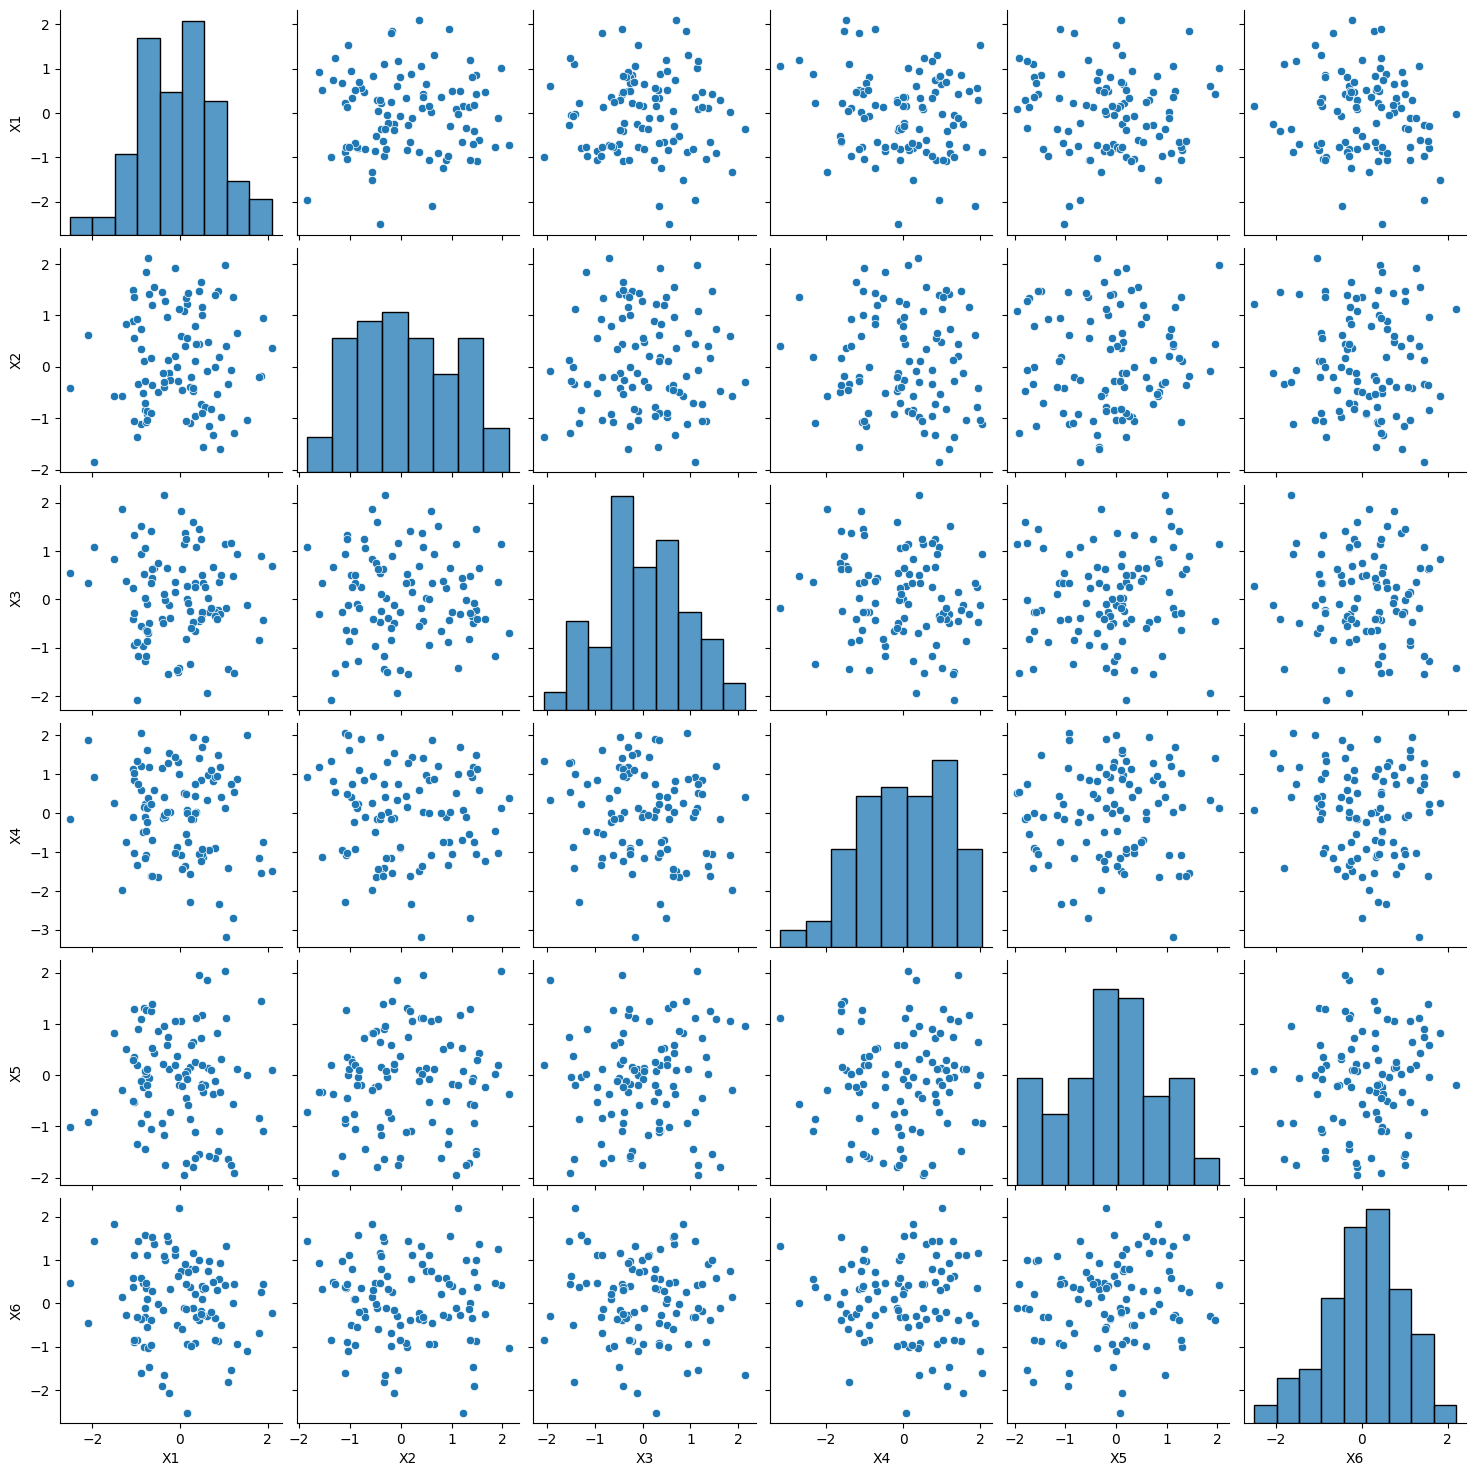

In [106]:
# Crea un pairplot para visualizar relaciones entre pares de variables.
sns.pairplot(df1)

'\nHistograma: ¿Como se distribuyen los datos por intervalos?\n'

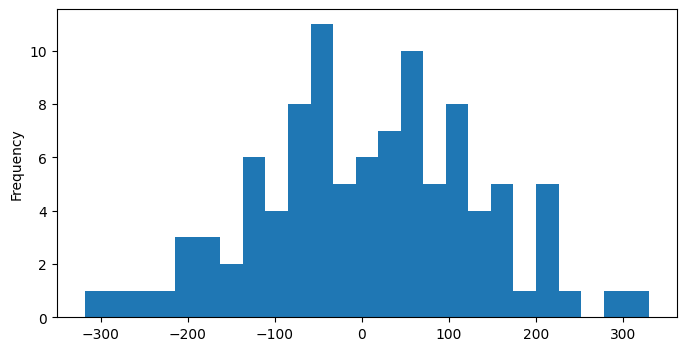

In [107]:
# Genera un histograma para mostrar la distribución de la variable objetivo 'y'.
df['y'].plot.hist(bins=25, figsize=(8,4))
'''
Histograma: ¿Como se distribuyen los datos por intervalos?
'''

'\nDensidad: ¿Donde estan concentrados los datos?\n'

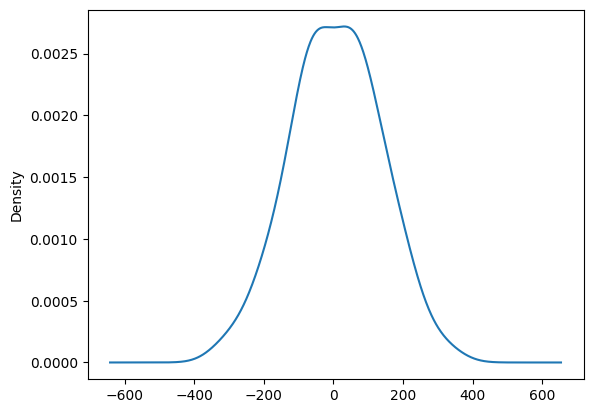

In [108]:
# Traza la estimación de densidad del kernel para la variable objetivo 'y'.
df['y'].plot.density()
'''
Densidad: ¿Donde estan concentrados los datos?
'''

In [69]:
# Calcula la matriz de correlación para las columnas numéricas.
numeric_df1 = df1.select_dtypes(include=[np.number])
numeric_df1.corr().round(4)

,X1,X2,X3,X4,X5,X6
X1,1.0000,0.0253,-0.0367,-0.1512,-0.0670,-0.1136
X2,0.0253,1.0000,-0.0089,-0.0560,0.0363,-0.0497
X3,-0.0367,-0.0089,1.0000,-0.1519,0.0796,-0.0564
X4,-0.1512,-0.0560,-0.1519,1.0000,0.0634,-0.1177
X5,-0.0670,0.0363,0.0796,0.0634,1.0000,0.1225
X6,-0.1136,-0.0497,-0.0564,-0.1177,0.1225,1.0000


'\nHoras de operación -> 0,84\nCarga -> 0,34\nTemperatura -> 0,098\nHumedad -> 0,063\n'

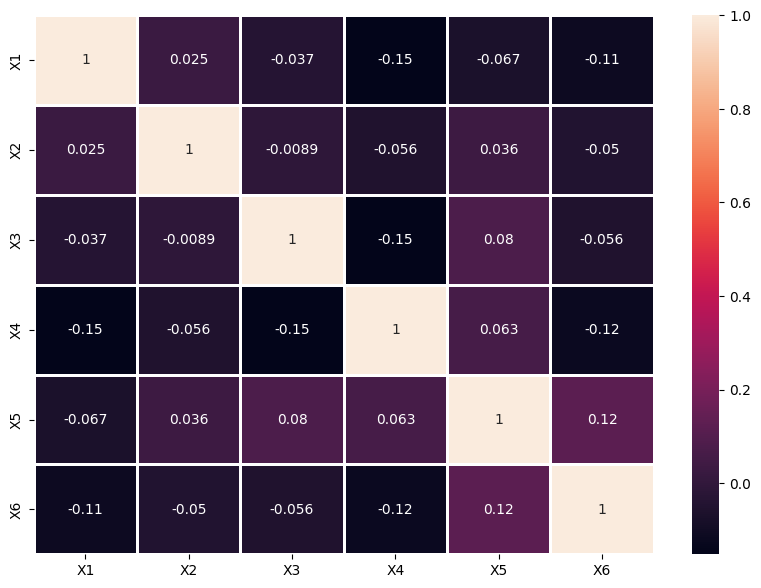

In [70]:
# Visualiza la matriz de correlación con un mapa de calor.
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df1.corr(), annot=True, linewidths=2)
'''
Horas de operación -> 0,84
Carga -> 0,34
Temperatura -> 0,098
Humedad -> 0,063
'''

In [71]:
# Obtiene una lista de nombres de columnas y su longitud.
one_column = list(df1.columns)
len_feature = len(one_column)
one_column

['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

In [72]:
# Divide el DataFrame en características (x) y variable objetivo (y).
x = df1[one_column[0:len_feature-1]]
len_feature = len(one_column)
y = df1[one_column[len_feature-1]]
x.head()

,X1,X2,X3,X4,X5
0,0.883893,0.195865,0.357537,-2.343262,-1.084833
1,0.939469,-0.978481,0.503097,0.406414,0.323461
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195
3,1.051109,0.406368,-0.168646,-3.189703,1.120132
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778


In [73]:
# Importa la función para dividir datos en conjuntos de entrenamiento y prueba.
from sklearn.model_selection import train_test_split

In [74]:
# Divide los datos en conjuntos de entrenamiento y prueba para modelado.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
    )

In [75]:
# Importa el modelo de regresión lineal y métricas de evaluación.
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [76]:
# Inicializa el modelo de regresión lineal.
lm= LinearRegression()

In [77]:
# Entrena el modelo de regresión lineal con los datos de entrenamiento.
lm.fit(x_train, y_train)

LinearRegression()

In [78]:
# Imprime el término de intercepción (constante) del modelo lineal.
print("el termino de interseccion del modelo lineal",lm.intercept_)

el termino de interseccion del modelo lineal 0.11709387496830988


In [79]:
# Imprime los coeficientes para cada característica del modelo lineal.
print("Los coeficientes del modelo lineal",lm.coef_)

Los coeficientes del modelo lineal [-0.21012262 -0.12090016 -0.10664408 -0.04872094  0.03478054]


In [80]:
# Crea un DataFrame con los coeficientes del modelo para cada característica.
cdf = pd.DataFrame(lm.coef_, x.columns, columns=['Coeficientes'])
cdf

,Coeficientes
X1,-0.210123
X2,-0.120900
X3,-0.106644
X4,-0.048721
X5,0.034781


In [81]:
# Calcula errores estándar y estadísticas t para los coeficientes.
n=x_train.shape[0]
k=x_train.shape[1]
dfN=n-k
train_pred=lm.predict(x_train)
train_error=np.square(train_pred - y_train)
sum_error=np.sum(train_error)
se=[0]*k # Inicializa la lista 'se' con el tamaño correcto 'k'
for i in range(k):
  r=(sum_error/dfN)
  r=r/np.sum(np.square(x_train[list(x_train.columns)[i]]-x_train[list(x_train.columns)[i]].mean()))
  se[i]=np.sqrt(r)


cdf['Standard Error']=se
cdf['t-statistic']=cdf['Coeficientes']/cdf['Standard Error']
cdf

IndexError: list assignment index out of range

KeyError: 'Consumo_Energia'

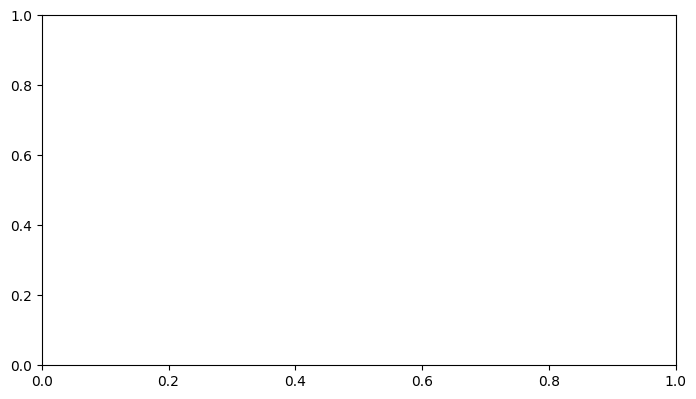

In [82]:
# Visualiza la relación entre cada característica y la variable objetivo 'y'.
l = list(cdf.index)

from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df1[l[0]], df['y']) # Usa df['y'] en lugar de df1['Consumo_Energia']
ax0.set_title(l[0] + " vs. Y", fontdict={'fontsize':20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df1[l[1]], df['y']) # Usa df['y'] en lugar de df1['Consumo_Energia']
ax1.set_title(l[1] + " vs. Y", fontdict={'fontsize':20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df1[l[2]], df['y']) # Usa df['y'] en lugar de df1['Consumo_Energia']
ax2.set_title(l[2] + " vs. Y", fontdict={'fontsize':20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df1[l[3]], df['y']) # Usa df['y'] en lugar de df1['Consumo_Energia']
ax3.set_title(l[3] + " vs. Y", fontdict={'fontsize':20})

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho (30,)


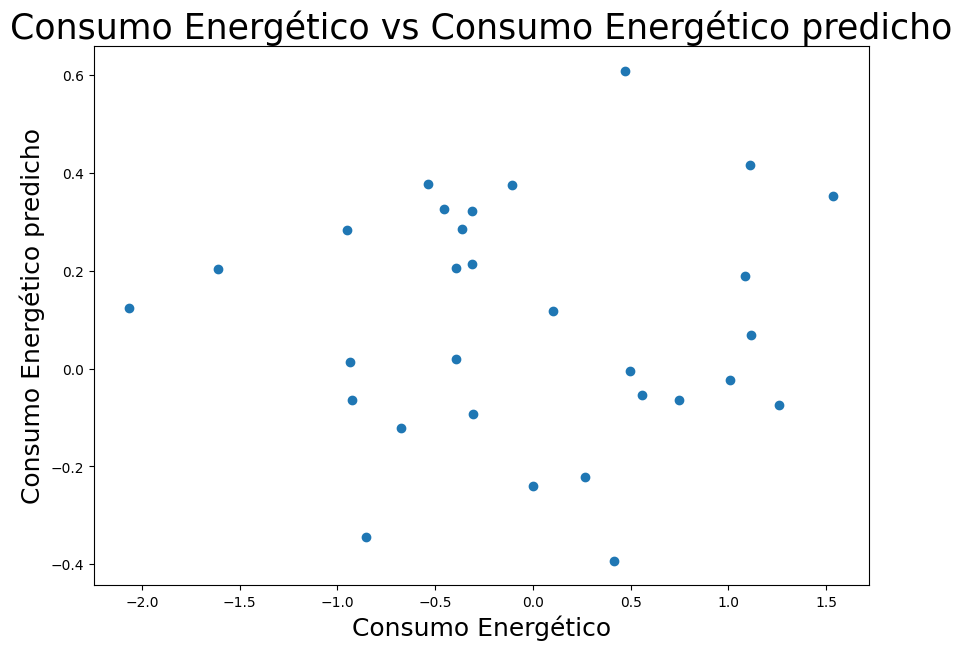

In [83]:
# Realiza predicciones y las compara con los valores reales.
predictions = lm.predict(x_test)
print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho", predictions.shape)
'''
Meta: Datos que caen en una linea de 45°
'''
plt.figure(figsize=(10,7))
plt.title("Consumo Energético vs Consumo Energético predicho", fontsize=25)
plt.xlabel("Consumo Energético", fontsize=18)
plt.ylabel("Consumo Energético predicho", fontsize=18)
plt.scatter(x=y_test, y=predictions)

/tmp/ipykernel_1759/3289311670.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([y_test - predictions])


<Axes: title={'center': 'Histograma de residuos para verificar la normalidad'}, xlabel='Residuos', ylabel='Densidad del kernel'>

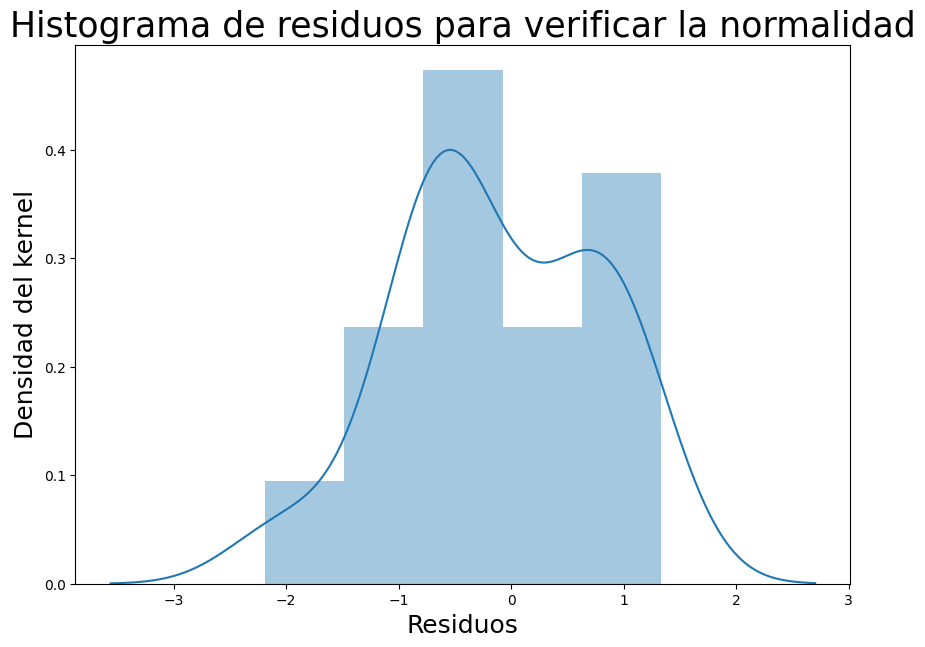

In [84]:
# Visualiza la distribución de los residuos para verificar la normalidad.
plt.figure(figsize=(10,7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=25)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.distplot([y_test - predictions])

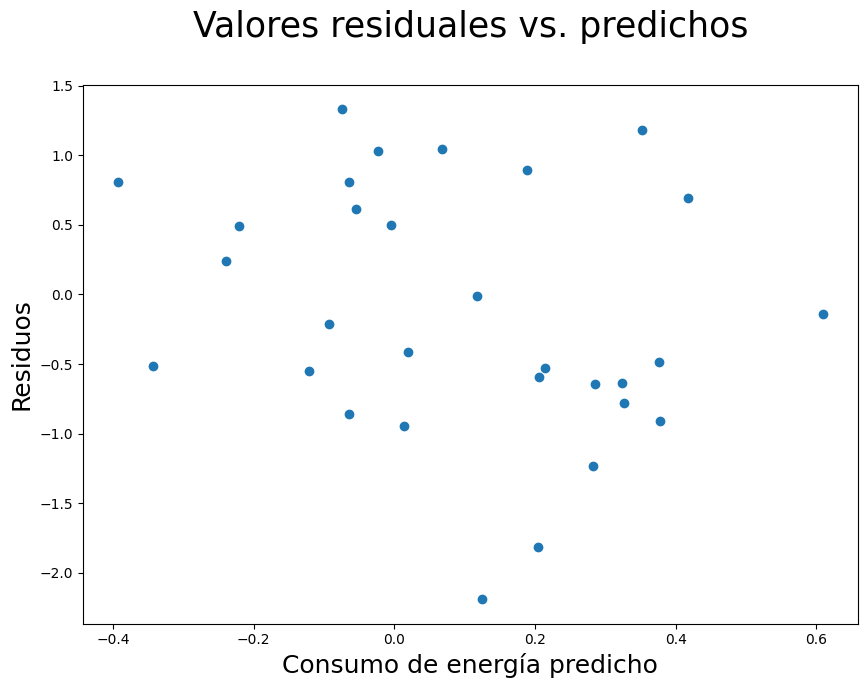

In [85]:
# Grafica residuos vs. valores predichos para evaluar la homocedasticidad.
plt.figure(figsize=(10,7))
plt.title("Valores residuales vs. predichos\n",fontsize=25)
plt.xlabel("Consumo de energía predicho",fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions,y=y_test-predictions)

In [86]:
# Importa bibliotecas necesarias y la función para generar datos de regresión.
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np

# Importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

In [87]:
# Define parámetros para la generación de datos de regresión sintéticos.
n_samples = 100 # Número de muestras
n_features = 6 # Número de características
n_informative = 3 # Número de características informativas i.e. características reales que influyen en la salida

In [88]:
# Genera datos sintéticos para un problema de regresión lineal.
X, y, coef = make_regression(n_samples=n_samples, n_features=n_features, n_informative=n_informative,
                             random_state=20, shuffle=False, noise=20, coef=True)
#                     semilla aleatoria (reproducibilidad)
#                     que no se mezclen las características
#                     ruido aleatorio
#                     devuelve los coef.
print(coef)

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


In [89]:
# Crea DataFrames para características (X) y variable objetivo (y).
df1 = pd.DataFrame(data=X, columns=['X'+str(i) for i in range(1,n_features+1)])
df2=pd.DataFrame(data=y, columns=['y'])
df=pd.concat([df1,df2],axis=1)
df.head(10)

,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


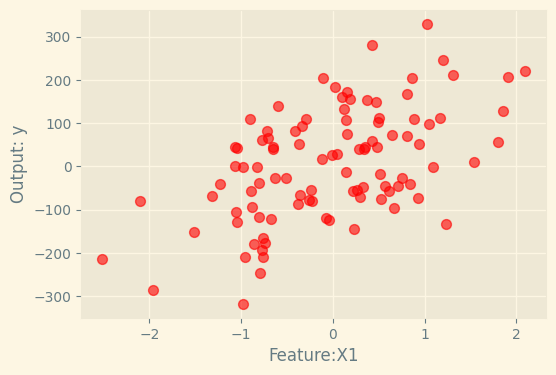

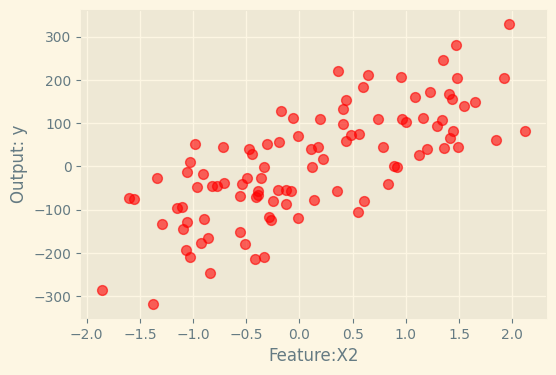

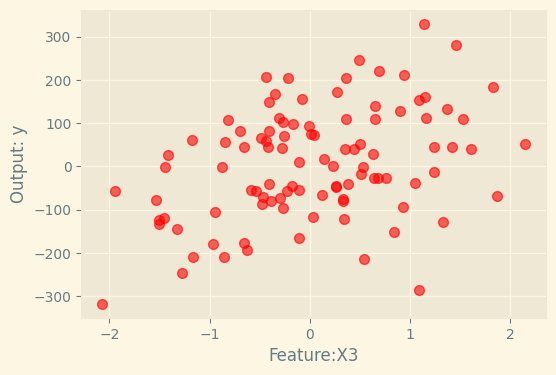

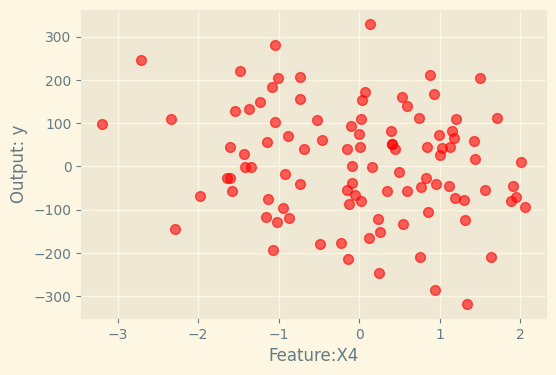

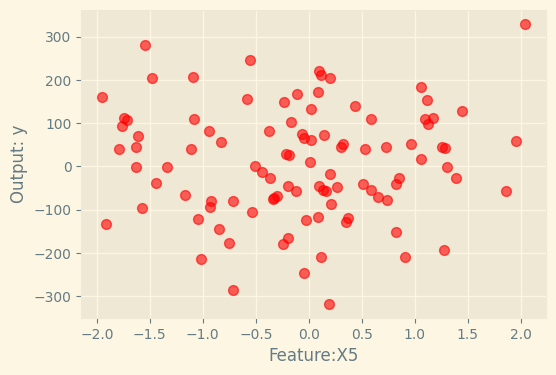

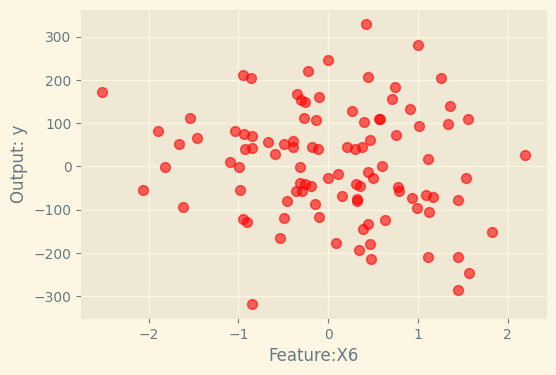

In [90]:
# Visualiza la relación entre cada característica y la variable objetivo 'y'.
with plt.style.context(('Solarize_Light2')):
    for i, col in enumerate(df.columns[:-1]):
        plt.figure(figsize=(6, 4))
        plt.grid(True)
        plt.xlabel('Feature:' + col, fontsize=12)
        plt.ylabel('Output: y', fontsize=12)
        plt.scatter(df[col], df['y'], c='red', s=50, alpha=0.6)

In [91]:
# Importa las bibliotecas necesarias para árboles de decisión y división de datos.
from sklearn import tree
from sklearn.model_selection import train_test_split

In [92]:
# Divide los datos sintéticos en conjuntos de entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

In [93]:
# Crea y entrena un modelo de árbol de decisión para regresión.
# Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
# niveles de decisión
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

In [94]:
# Importa la biblioteca de métricas para evaluar el rendimiento del modelo.
from sklearn import metrics

Mean square error (MSE): 7931.574768958281


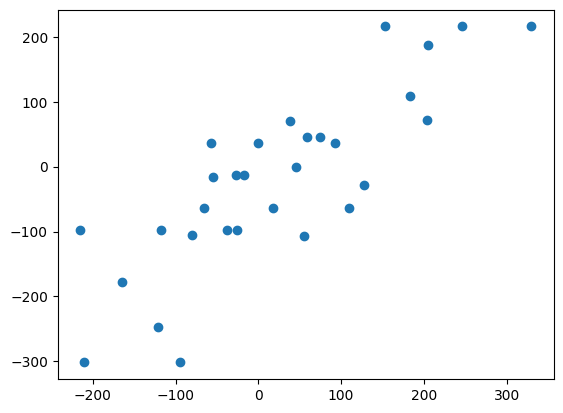

In [95]:
# Realiza predicciones con el árbol de decisión y evalúa el MSE.
# Hacemos predicciones
test_pred = tree_model.predict(X_test)
plt.scatter(x=y_test, y=test_pred)  # real vs predicho
print("Mean square error (MSE):", metrics.mean_squared_error(y_test, test_pred))
# Error cuadrático medio

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


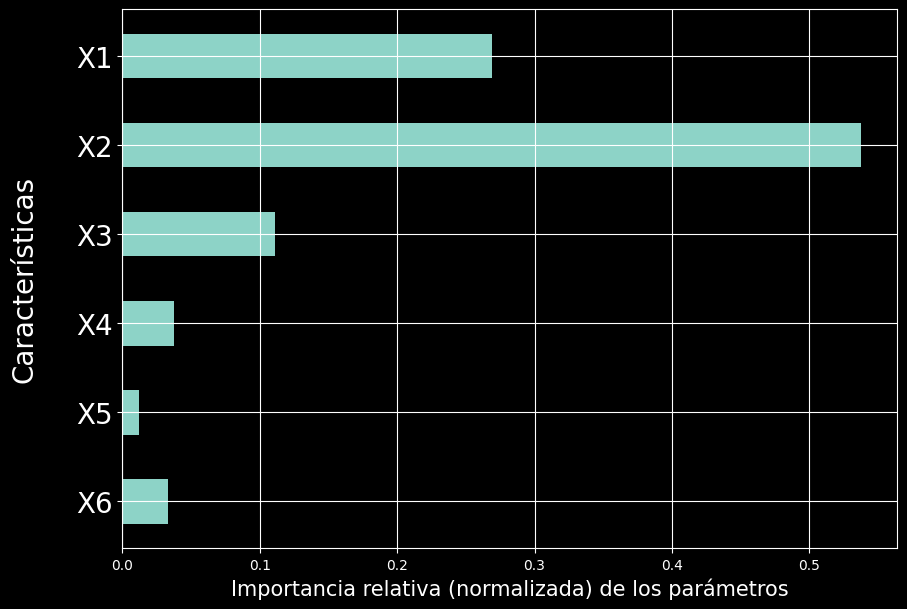

In [96]:
# Muestra la importancia de cada característica en el árbol de decisión.
print("Importancia relativa de las características: ", tree_model.feature_importances_)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features+1, 1, -1), df.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features+1, 1, -1), width=tree_model.feature_importances_, height=0.5)

In [97]:
# Importa la biblioteca statsmodels para análisis estadístico más detallado.
import statsmodels.api as sm

In [98]:
Xs=sm.add_constant(X) # Añade una constante (intercepción) a las variables predictoras
stat_model = sm.OLS(y, Xs) # Crea el modelo de Mínimos Cuadrados Ordinarios (OLS)
stat_result = stat_model.fit() # Ajusta el modelo a los datos
print(stat_result.summary()) # Muestra el resumen estadístico del modelo

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        21:42:43   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0